In [1]:
# import packages

# to manipulate data
import numpy as np
import pandas as pd

# to handle files
import os

# to visualize
import matplotlib.pyplot as plt

# to check distribution
import scipy.stats as stats

# to encode
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

# to split X and y into test and train set
from sklearn.model_selection import train_test_split

# to build LinearRegression model
from sklearn.linear_model import LinearRegression

# to build Random Forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# to evaluate model
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict

## EDA

In [2]:
# import dataset
import kagglehub

# download latest version
path = kagglehub.dataset_download("mirichoi0218/insurance")

print("Path to dataset files:", path)

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /home/codespace/.cache/kagglehub/datasets/mirichoi0218/insurance/versions/1


In [3]:
os.listdir(path)

['insurance.csv']

In [4]:
# load to dataframe
path_to_csv = path + "/" + "insurance.csv"
df = pd.read_csv(path_to_csv)

In [5]:
# basic info about the df
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
# check missing values
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [8]:
# split y and X
y = df['charges']
X = df.drop('charges', axis = 1)

In [9]:
cols_to_bar = ['sex', 'children', 'smoker', 'region']
cols_to_kde = ['age', 'bmi']

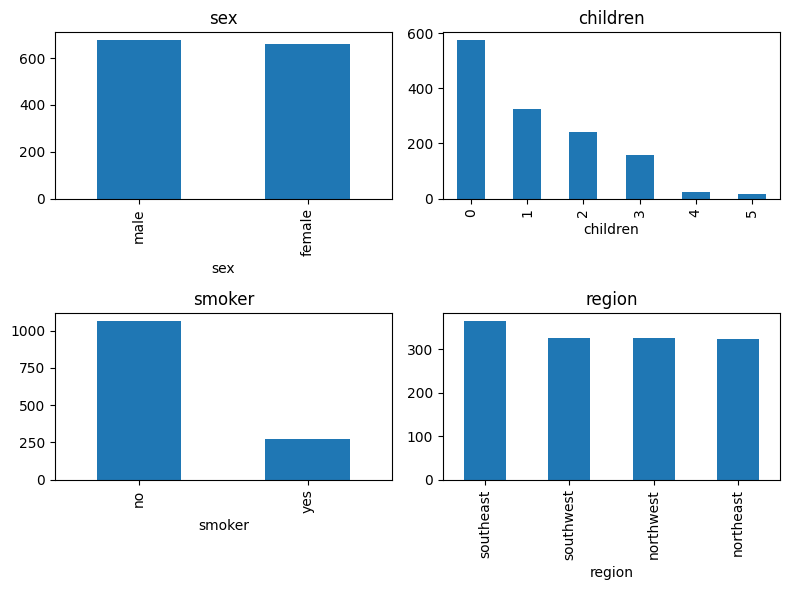

In [10]:
# for sex, children, smoker, region, 
fig, axs = plt.subplots(
    nrows=2, 
    ncols=2, 
    figsize=(8, 6))
axs = axs.flatten()

for i, col in enumerate(cols_to_bar):
    data = X[col].value_counts()
    data.plot(kind='bar', ax=axs[i])
    axs[i].set_title(col)

plt.tight_layout()
plt.show()

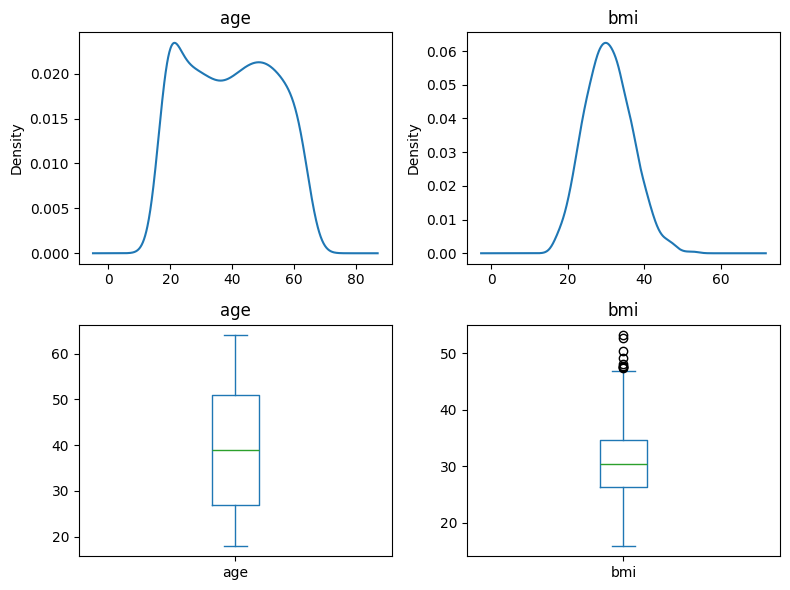

In [11]:
# for age and bmi
fig, axs = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(8,6))
axs = axs.flatten()

for i, col in enumerate(cols_to_kde):
    data = X[col]
    data.plot(kind='kde', ax=axs[i])
    data.plot(kind='box', ax=axs[i+2])
    axs[i].set_title(col)
    axs[i+2].set_title(col)

plt.tight_layout()
plt.show()

# ('line', 'bar', 'barh', 'kde', 'density', 'area', 'hist', 'box', 'pie', 'scatter', 'hexbin')

In [12]:
# log transform bmi to reduce skewness
X['log_bmi'] = np.log(X['bmi'])

<Axes: >

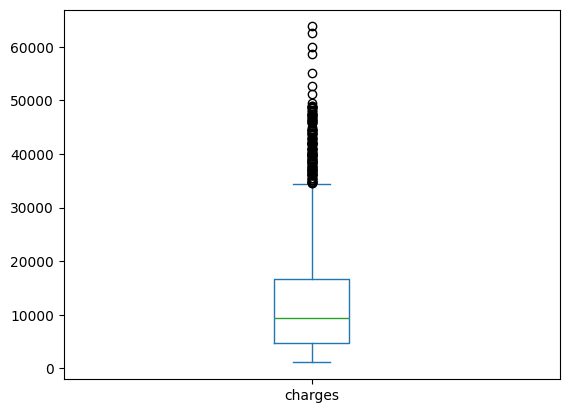

In [13]:
# for y - charges
y.plot(kind='box')

<Axes: >

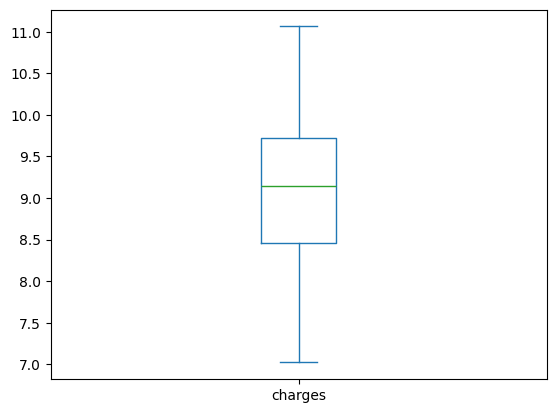

In [14]:
# log transform y to reduce skewness
log_y = np.log(y)
log_y.plot(kind='box')

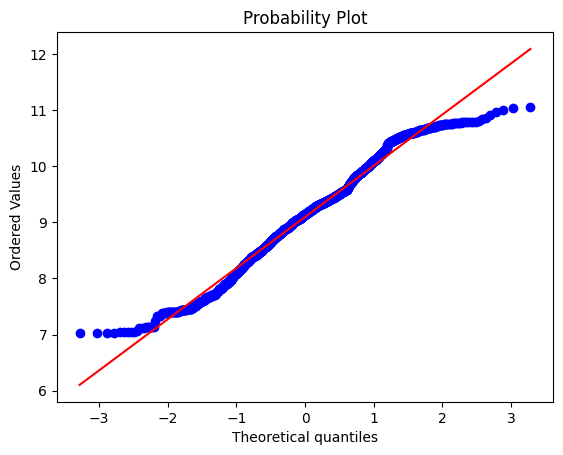

In [15]:
# check if y is normal distribution
stats.probplot(log_y, dist="norm", plot=plt)
plt.show()

# A Probability Plot is a graphical technique used to assess whether a dataset follows a specific theoretical distribution
# by plotting data against calculated probabilities. 
# Points forming a straight line indicate a good fit, while deviations indicate departures from the distribution. 

## Encode

In [16]:
# Encode:
# age, log_bmi, children: No Encode (numeric data)
# sex, smoker: label encoding (binary data)
# region: one hot encoder (nominal data)

In [17]:
# label encoder
le = LabelEncoder()

X['sex'] = le.fit_transform(X['sex'])
X['smoker'] = le.fit_transform(X['smoker'])

In [18]:
# one hot encoder
ohe = OneHotEncoder(sparse_output=False)
region_encoded = ohe.fit_transform(X[['region']]) 

In [19]:
# encode region data frame
region_df = pd.DataFrame(region_encoded, columns=ohe.get_feature_names_out(['region']))

In [20]:
# merge with X df, drop original column
X = X.drop('region', axis=1).join(region_df)

In [21]:
X.head()

,age,sex,bmi,children,smoker,log_bmi,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,3.328627,0.0,0.0,0.0,1.0
1,18,1,33.770,1,0,3.519573,0.0,0.0,1.0,0.0
2,28,1,33.000,3,0,3.496508,0.0,0.0,1.0,0.0
3,33,1,22.705,0,0,3.122585,0.0,1.0,0.0,0.0
4,32,1,28.880,0,0,3.363149,0.0,1.0,0.0,0.0


## Model

In [22]:
# split X and y into test and train set
X_train, X_test, y_train, y_test = train_test_split(X, log_y, test_size=0.3, random_state=42)

### Simple Linear Regression

In [23]:
# simple linear
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [24]:
# predict with test set
y_test_pred = model.predict(X_test)

In [25]:
# metrics

# Mean Absolute Error (MAE): The average of the absolute differences between predictions and actual values
# Mean Squared Error (MSE): The average of the squared differences (penalizes larger errors more heavily)
# Root Mean Squared Error (RMSE): The square root of MSE, which is in the same units as the target variable
# R² (R-squared) Score: Represents the proportion of variance in the dependent variable that is predictable

In [26]:
# create a dataframe to input results
df_results = pd.DataFrame()

In [27]:
# create funtion to evaluate model
def evaluate_log(model, model_name, X_train, y_train, y_test, y_test_pred):
    # Cross validation
    cv_rmse = cross_val_score(
        model, 
        X_train, 
        y_train, 
        scoring="neg_root_mean_squared_error", 
        cv=5)
    
    # Calculate metrics
    mae = mean_absolute_error(y_test, y_test_pred)
    mse = mean_squared_error(y_test, y_test_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_test_pred)
    
    # Print results
    print(f'CV RMSE: {cv_rmse.mean():.2f}')
    print(f'MAE: {mae:.2f}')
    print(f'MSE: {mse:.2f}')
    print(f'RMSE: {rmse:.2f}')
    print(f'R2: {r2:.2f}')
    
    # Results
    results = {
        "Model": model_name,
        "CV RMSE": cv_rmse.mean(),
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }
    
    return results

In [28]:
# evaluate
result_lr_log = evaluate_log(model, "Linear Regression - Log", X_train, y_train, y_test, y_test_pred)
df_results = pd.concat([df_results, pd.DataFrame([result_lr_log])], ignore_index=True)

CV RMSE: -0.45
MAE: 0.27
MSE: 0.18
RMSE: 0.42
R2: 0.78


In [29]:
# create funtion to evaluate model wwith orrignal value
def evaluate_original(model, model_name, X_train, y_train, X_test, y_test, y_test_pred):
    
    y_test_original = np.exp(y_test)
    y_pred_original = np.exp(y_test_pred)
    
    y_train_cv_pred_log = cross_val_predict(model, X_train, y_train, cv=5)
    y_train_original = np.exp(y_train)
    y_train_cv_pred_original = np.exp(y_train_cv_pred_log)
    cv_rmse_original = np.sqrt(mean_squared_error(y_train_original, y_train_cv_pred_original))
    
    mae_original = mean_absolute_error(y_test_original, y_pred_original)
    mse_original = mean_squared_error(y_test_original, y_pred_original)
    rmse_original = np.sqrt(mse_original)
    r2_original = r2_score(y_test_original, y_pred_original)
    
    print(f'CV RMSE: ${cv_rmse_original:,.2f}')
    print(f'MAE:  ${mae_original:,.2f}')
    print(f'RMSE: ${rmse_original:,.2f}')
    print(f'R2:   {r2_original:.2f}')

    # Results
    results = {
        "Model": model_name,
        "CV RMSE": cv_rmse_original.mean(),
        "MAE": mae_original,
        "RMSE": rmse_original,
        "R2": r2_original
    }
    
    return results

In [30]:
results_lr_original = evaluate_original(model, "Linear Regression - Original", X_train, y_train, X_test, y_test, y_test_pred)
df_results = pd.concat([df_results, pd.DataFrame([results_lr_original])], ignore_index=True)

CV RMSE: $8,743.44
MAE:  $3,800.40
RMSE: $7,631.41
R2:   0.60


### Random Forest Regression

In [31]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [32]:
# initiate a random forest
rf = RandomForestRegressor(random_state = 42)

In [33]:
# GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,                    
    scoring='neg_mean_squared_error',  
    n_jobs=-1,               
    verbose=2                
)

In [34]:
# find best parameter
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.7s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.7s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   1.1s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   1.0s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   1.1s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.3s
[CV] END max_depth=10, min_sa

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 15, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time fo

In [35]:
# best params
grid_search.best_params_

{'max_depth': 10,
 'min_samples_leaf': 4,
 'min_samples_split': 10,
 'n_estimators': 200}

In [36]:
best_rf = grid_search.best_estimator_

In [37]:
y_test_pred = best_rf.predict(X_test)

In [38]:
# evaluate
result_rf_log = evaluate_log(model, "Random Forest - Log", X_train, y_train, y_test, y_test_pred)
df_results = pd.concat([df_results, pd.DataFrame([result_rf_log])], ignore_index=True)

CV RMSE: -0.45
MAE: 0.19
MSE: 0.14
RMSE: 0.37
R2: 0.83


In [39]:
results_rf_original = evaluate_original(model, "Random Forest - Original", X_train, y_train, X_test, y_test, y_test_pred)
df_results = pd.concat([df_results, pd.DataFrame([results_rf_original])], ignore_index=True)

CV RMSE: $8,743.44
MAE:  $2,017.59
RMSE: $4,334.65
R2:   0.87


In [40]:
df_results.style.format({
    'CV RMSE': '{:.2f}',
    'MAE': '{:.2f}',
    'RMSE': '{:.2f}',
    'R2': '{:.2f}'
})

,Model,CV RMSE,MAE,RMSE,R2
0,Linear Regression - Log,-0.45,0.27,0.42,0.78
1,Linear Regression - Original,8743.44,3800.40,7631.41,0.60
2,Random Forest - Log,-0.45,0.19,0.37,0.83
3,Random Forest - Original,8743.44,2017.59,4334.65,0.87
